# Kalman Filter: constant velocity

This notebook demonstrates a **1D Kalman filter** estimating **position and velocity** from **noisy position measurements**.

## 1. Model overview

The real behavior of the system is modeled as a moving particle driven by random jerk.

Hence, the state consists of position $x$, velocity $v$ and acceleration $a$.
The true dynamics of the point mass is assumed to be described by the state
equations (modeling accelerated motion)

$$
\begin{bmatrix} x_{k+1} \\ v_{k+1} \\ a_{k+1} \end{bmatrix} =  A \begin{bmatrix} x_k \\ v_k \\ a_k \end{bmatrix} + \mathsf{w}_k %B_k j_k
$$

with process noise $\mathsf{w}_k\sim\mathcal{N}(0,Q)$ where

$$
% A = \begin{bmatrix}1 & dt\\ 0 & 1\end{bmatrix},\quad
%B = \begin{bmatrix}\tfrac{1}{2}dt^2\\ dt\end{bmatrix}
A = \begin{bmatrix} 1 & dt & \tfrac{1}{2}dt^2 \\ 0 & 1  & dt \\ 0 & 0  & 1 \end{bmatrix},\quad
Q = \sigma_j^2 \begin{bmatrix} \tfrac{dt^5}{20} & \tfrac{dt^4}{8} & \tfrac{dt^3}{6} \\ \tfrac{dt^4}{8}  & \tfrac{dt^3}{3} & \tfrac{dt^2}{2} \\ \tfrac{dt^3}{6}  & \tfrac{dt^2}{2} & dt \end{bmatrix}.
$$

The above DT system can be obtained from the exact discretization of a continous-time
system driven by jerk white noise $j(t)$ with intensity $\sigma_j^2$, i.e.
$\mathbb{E}[j(t)]=0$ and $\mathbb{E}[j(t)j(\tau)]=\sigma_j^2\delta(t-\tau)$
<!-- $\sim\mathcal{N}(0,\sigma_j^2)$ (randomly changing) -->

Finally, for now, we assume position only measurements
$$
y^{(pos)}_k = H \begin{bmatrix} x_k \\ v_k \\ a_k \end{bmatrix} + \mathsf{v}_k,\quad 
$$
where $H=\begin{bmatrix}1 & 0 & 0\end{bmatrix}$ and $\mathsf{v}_k\sim\mathcal{N}(0,R), R=\sigma_{\mathsf{v}}^2$.

## 2. Imports and setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from linear_and_nonlinear_kf.utils import simulate_linear_model  # used to simulate motion and measurements

## 2. Kalman filter (constant velocity model)

The filter considers a constant velocity model having, at this time, no notion of acceleration.

$$
\begin{bmatrix} x_{k+1} \\ v_{k+1} \end{bmatrix} =  A \begin{bmatrix} x_k \\ v_k \end{bmatrix} + \mathsf{w}_k
$$
with process noise $\mathsf{w}_k\sim\mathcal{N}(0,Q)$, where 

$$
A = \begin{bmatrix} 1 & dt \\ 0 & 1 \end{bmatrix}, \quad
Q = \sigma_a^2\begin{bmatrix}\tfrac{dt^4}{4} & \tfrac{dt^3}{2} \\ \tfrac{dt^3}{2} & dt^2 \end{bmatrix}
$$

assuming process noise is due to random white acceleration.

The measurement model is similar to the one above, i.e.

$$
y^{(pos)}_k = H \begin{bmatrix} x_k \\ v_k \end{bmatrix} + \mathsf{v}_k,\quad 
$$
where $H=\begin{bmatrix}1 & 0 \end{bmatrix}$ and $\mathsf{v}_k\sim\mathcal{N}(0,R), R=\sigma_{\mathsf{v}}^2$.


In [10]:
def kalman_filter_constant_velocity(y: np.ndarray,
                                    dt: float,
                                    x0: np.ndarray,
                                    P0: np.ndarray,
                                    sigma_a: float,
                                    sigma_y: float):
    """
    Implement KF equations moving point in 1D assuming a constant velocity model.

    Args:
        y (np.ndarray): array of noisy measurements.
        dt (float): time step.
        x0 (np.ndarray): initial state [position, velocity].
        P0 (np.ndarray): initial covariance matrix.
        sigma_a (float): standard deviation of process noise (acceleration) of the filter.
        sigma_y (float): standard deviation of measurement noise of the filter.

    Returns:
        np.ndarray: array of estimated states [position, velocity] at each time step.
        List[np.ndarray]: list of covariance error matrix at each time step.
    """
    A = np.array([[1.0, dt], [0.0, 1.0]])
    H = np.array([[1.0, 0.0]])
    R = np.array([[sigma_y**2]])
    B = np.array([[0.5*dt**2], [dt]])  # used only to compute process cov Q
    Q = sigma_a**2 * B @ B.T

    I = np.eye(2)
    x = x0.reshape(2, 1)
    P = P0.copy()

    xs = []
    Ps = []

    for yk in y:
        # Measurements
        yk = np.array([[yk]])

        # Predict
        x_pred = A @ x
        P_pred = A @ P @ A.T + Q

        # Update
        e = yk - H @ x_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        x = x_pred + K @ e
        P = (I - K @ H) @ P_pred

        xs.append(x.flatten())
        Ps.append(P.copy())

    return np.array(xs), np.array(Ps)

## 3. Run simulation and filter

In [ ]:
# define the parameters
dt = 0.1
n_steps = 200
p0 = 0
v0 = 0
a0 = 0

# true values used to generate motion
sigma_j_true = 0.8
sigma_y_true = 2.0

# generate the "true" motion and measurements. acceleration measurements saved just for checking
true_pos, true_vel, true_acc, y, y_acc = simulate_linear_model(
    n_steps, dt,
    p0, v0, a0,
    sigma_j_true, sigma_y_true, -1,
    seed=42
)

# defined the filter noise parameters
# Currently equal to the true ones -> This is the best we can do!!!
sigma_a_filter = 0.8
sigma_y_filter = 2.0

# initialize the filter: state estimate and error cov matrix
x0 = np.array([0.0, 0.0])
P0 = np.diag([10.0**2, 10.0**2])

# run the filter
xs, Ps = kalman_filter_constant_velocity(
    y, dt, x0, P0, sigma_a_filter, sigma_y_filter
)

# extract the results
est_pos = xs[:, 0]
est_vel = xs[:, 1]
t = np.arange(n_steps) * dt  # time vector for plotting
sigma_pos = np.sqrt(Ps[:, 0, 0])
sigma_vel = np.sqrt(Ps[:, 1, 1])

# some MSE computations
mse_pos = np.mean((true_pos - est_pos)**2)
mse_vel = np.mean((true_vel - est_vel)**2)

print(f"Position MSE: {mse_pos:.4f}")
print(f"Velocity MSE: {mse_vel:.4f}")

# compute alternative estimates
est_vel_from_z = np.diff(y) / dt # naive estimates
est_vel_from_est_pos = np.diff(est_pos) / dt # from pos estimates
t_est_vel = t[1:]   # shorter by one


Position MSE: 33.1493
Velocity MSE: 29.8986


## 4. Results: Position and Velocity - True vs Estimated

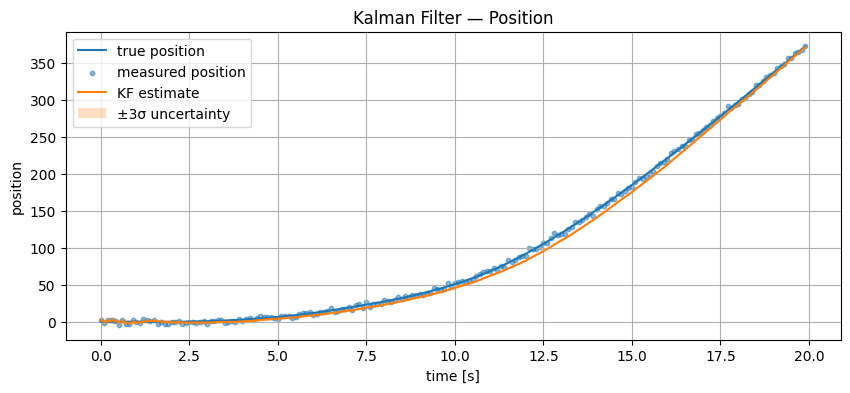

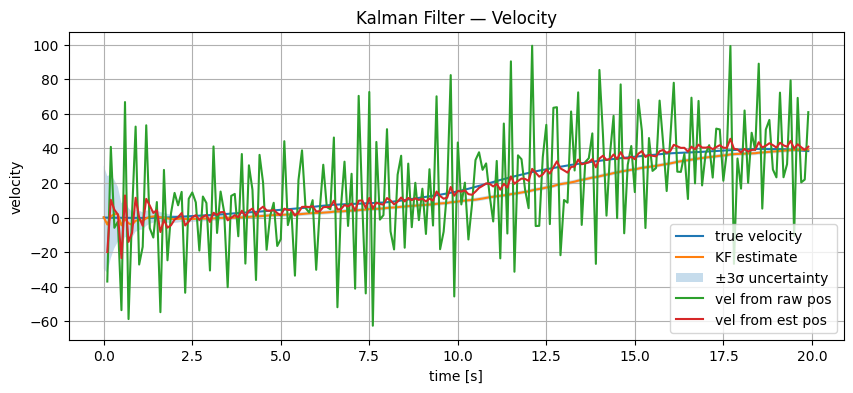

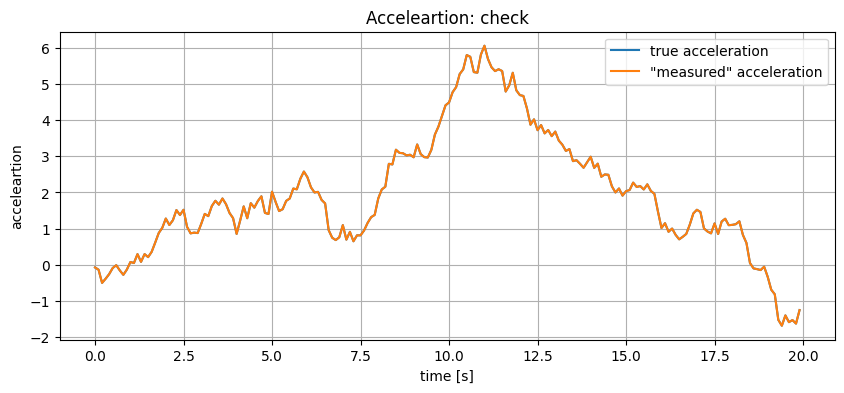

In [12]:
# plot the position
plt.figure(figsize=(10, 4))
plt.plot(t, true_pos, label='true position')
plt.scatter(t, y, s=10, alpha=0.5, label='measured position')
plt.plot(t, est_pos, label='KF estimate')
plt.fill_between(t, est_pos - 3*sigma_pos, est_pos + 3*sigma_pos, alpha=0.25, label="±3σ uncertainty")
plt.xlabel('time [s]')
plt.ylabel('position')
plt.title('Kalman Filter — Position')
plt.legend()
plt.grid(True)
plt.show()


# plot the velocity
plt.figure(figsize=(10, 4))
plt.plot(t, true_vel, label='true velocity')
plt.plot(t, est_vel, label='KF estimate')
plt.fill_between(t, est_vel - 3*sigma_vel, est_vel + 3*sigma_vel, alpha=0.25, label="±3σ uncertainty")
plt.plot(t_est_vel, est_vel_from_z, label="vel from raw pos")
plt.plot(t_est_vel, est_vel_from_est_pos, label="vel from est pos")
plt.xlabel('time [s]')
plt.ylabel('velocity')
plt.title('Kalman Filter — Velocity')
plt.legend()
plt.grid(True)
plt.show()

# plot the acceleration JUST FOR CHECKING
plt.figure(figsize=(10, 4))
plt.plot(t, true_acc, label='true acceleration')
plt.plot(t, y_acc, label='"measured" acceleration')
plt.xlabel('time [s]')
plt.ylabel('acceleartion')
plt.title('Acceleartion: check')
plt.legend()
plt.grid(True)
plt.show()

